# Score Display

This notebook reads a sample score and displays it as notation and as a piano
roll visualization.

In [4]:
# we could import just the functions we need, but for simplicity we'll import 
# everything ...
from amads.all import *

In [5]:
# Find the path to a MusicXML file for display.
xml_file = example.fullpath("musicxml/short2staff.mxl")
assert xml_file is not None

# Just to avoid unnecessary output, we'll ask read_score to be quiet:
set_reader_warning_level("none")

# Now read the score and show some minimal information to confirm:
score = read_score(xml_file)
score, len(score.list_all(Note))  # how many notes are in this score? (10)

(Score(onset=0.000, duration=8.000, units=quarters), 10)

## With Open Sheet Music Display (OSMD)

In [6]:
# Since it has fewer dependencies, we will use OSMD to display the score.
# This should display music notation in your browser.

# Normally, do this once at the start of your program, not every time you
# want to display a score:
set_preferred_display_method("OSMD")

# Display the score:
display_score(score)

# The console output will show the path to the MusicXML file created.

Exporting /var/folders/17/hkypxt_x3qn67vrqs7dplbgw0000gn/T/amads_display_85wv372f.musicxml using musicxml writer music21_export from subsystem music21.


### Starting with a MusicXML File
If you already have a MusicXML file (as in the example above), you can
display it directly without reading into a Score object and then writing
it back out (which will undoubtedly introduce at least minor changes).

This example will use OSMD as the display method because we selected
that in the previous cell.

In [7]:
# Display our xml_file directly:
display_file(xml_file)

## Piano-roll display

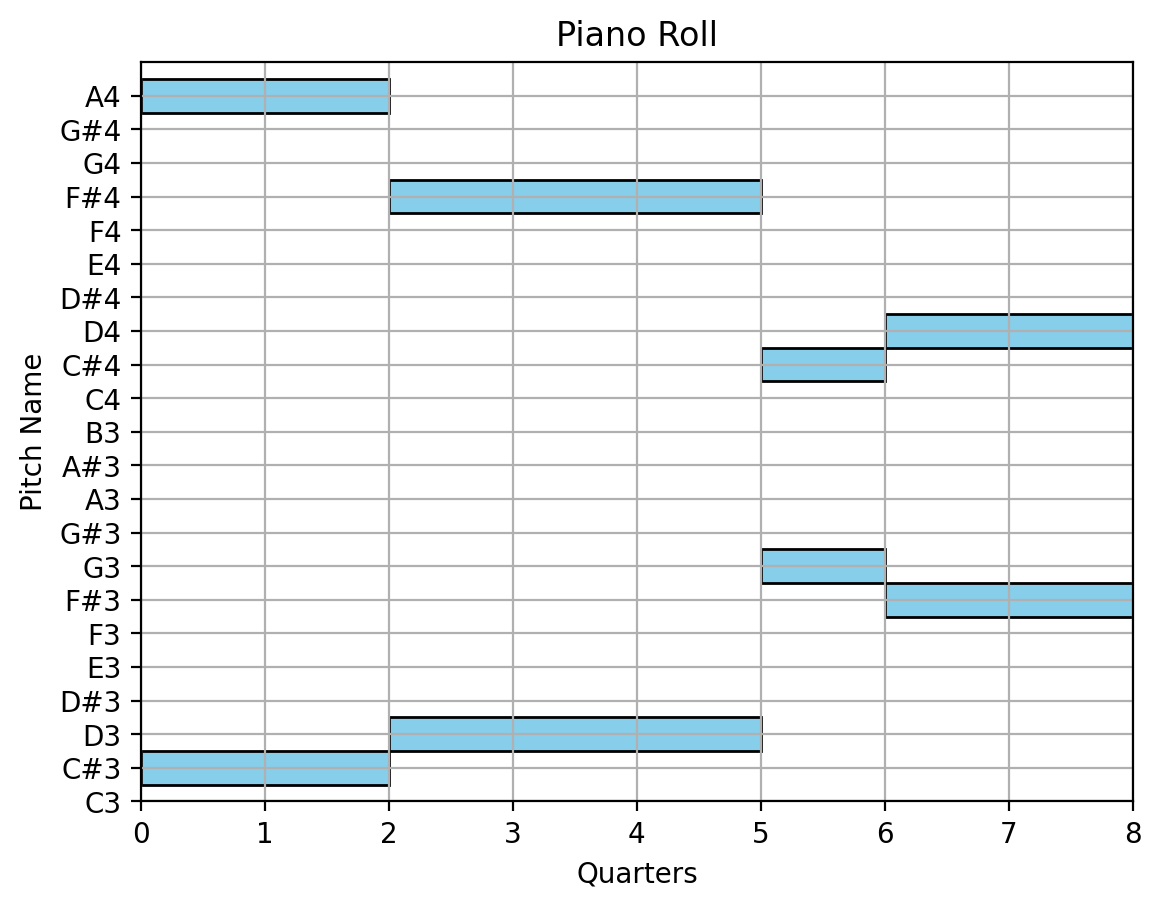

In [8]:
# To create a pianoroll display, you only need to change the preferred
# display method and then call display_score again:
set_preferred_display_method("pianoroll")
display_score(score)

The Piano Roll display is also good for MIDI data, especially data that is not
quantized and may not have a simple music notation transcription.

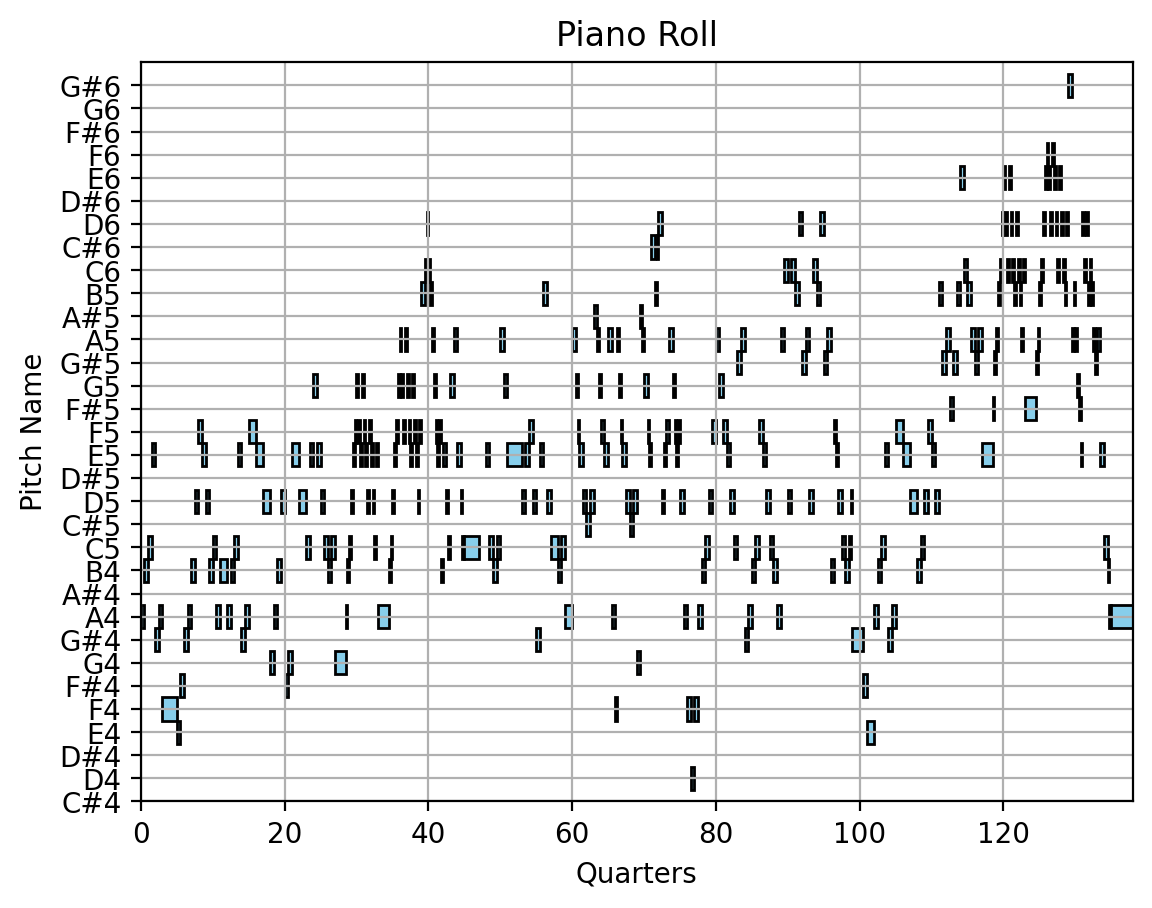

In [9]:
# Find the path to a Standard MIDI File for display.
midi_file = example.fullpath("midi/sarabande.mid")
assert midi_file is not None

# Read the MIDI file and display it as a pianoroll:
sarabande = read_score(midi_file)
# Note that displayscore.preferred_display_method is still "pianoroll".
display_score(sarabande)

If you run display_score outside of this notebook, you will get an interactive
plot where you can zoom in and get exact times from mouse position.

# More Display Possibilities

In the remainder of this notebook, we show code to display our xml_file
using different rendering methods based on Lilipond, Music21, and MuseScore.

## PDF display via LilyPond-related backends

When the display method is `pdf`, AMADS can use multiple writer backends.
This example will use Music21 to write to Lilypond, which can create the
PDF file.

In [10]:
set_preferred_display_method("pdf")
set_preferred_pdf_writer("music21-lilypond")
display_score(sarabande)

Exporting /var/folders/17/hkypxt_x3qn67vrqs7dplbgw0000gn/T/amads_1ws7ojo6/temp.pdf using pdf writer music21_pdf_export from subsystem music21-lilypond.


### Best
This example will use Music21 to write a MusicXML file, which is converted by a
Lilypond utility to Lilypond, which then creates the PDF file. 
"music21-xml-lilypond" creates the best PDF for this piece.

In [11]:
set_preferred_pdf_writer("music21-xml-lilypond")
display_score(sarabande)

Exporting /var/folders/17/hkypxt_x3qn67vrqs7dplbgw0000gn/T/amads_0kpk7f49/temp.pdf using pdf writer music21_xml_pdf_export from subsystem music21-xml-lilypond.


This example is similar, but instead of Music21, we use Partitura to write the
MusicXML. Then, as before, a Lilypond utility converts MusicXML to Lilypond
format, and Lilypond creates the PDF file.

In [12]:
set_preferred_pdf_writer("partitura-xml-lilypond")
display_score(sarabande)

Exporting /var/folders/17/hkypxt_x3qn67vrqs7dplbgw0000gn/T/amads_rtzn6fl2/temp.pdf using pdf writer partitura_xml_pdf_export from subsystem partitura-xml-lilypond.


## MuseScore display

You can also run MuseScore if it is installed and load MusicXML, which is
created by whichever subsystem is the `preferred_xml_writer`. The default,
which is now in effect, is "music21", so `display_score` will use Music21
to write MusicXML, which will be displayed by MuseScore.

In [13]:
set_preferred_display_method("musescore")
display_score(sarabande)

Exporting /var/folders/17/hkypxt_x3qn67vrqs7dplbgw0000gn/T/amads_display_ijy78n70.musicxml using musicxml writer music21_export from subsystem music21.


## Display PDF in a Notebook
To a limited extent, you can put music notation right into your notebook, but
you need to `pip3 install pdf2image` and also your system must have poppler
installed, e.g., with `brew install poppler`

Exporting /var/folders/17/hkypxt_x3qn67vrqs7dplbgw0000gn/T/tmpr_8z8n72_amads/score.pdf using pdf writer partitura_xml_pdf_export from subsystem partitura-xml-lilypond.


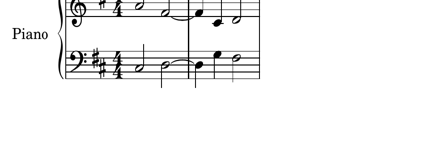

In [14]:
from IPython.display import display
from tempfile import mkdtemp
from pdf2image import convert_from_path
from PIL import Image

# Create a temporary directory to store the PDF file by passing in None.
# If filename is None, you need to give an explicit format ("pdf")
pdf_path = write_score(score, None, False, "pdf")
images = convert_from_path(pdf_path)
image = images[0]  # get the first page as an image

# you can select a subimage with tuple (left, upper, right, lower):
image = image.crop((50, 100, 1000, 400))
# you can then resize the image (half-size here):
image = image.resize((425, 150))  

display(image)


## Restore defaults

In [15]:
set_preferred_pdf_writer()
set_preferred_display_method()
set_preferred_xml_writer()

'music21'